In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import plotly.graph_objects as go


In [ ]:
try:
    df = pd.read_csv('Wash_shuffle.csv')
except FileNotFoundError as e:
    raise FileNotFoundError(
        "Wash_shuffle.csv not found. Run this notebook from the 'notebooks/' directory or update the path."
    ) from e

REQUIRED_COLUMNS = {'Trials', 'Start Position', 'End Position', 'Card Number'}
missing = REQUIRED_COLUMNS - set(df.columns)
if missing:
    raise ValueError(f"CSV missing expected columns: {missing}")

for col in ('Trials', 'Start Position', 'End Position'):
    coerced = pd.to_numeric(df[col], errors='coerce')
    bad_rows = df.index[coerced.isna() & df[col].notna()].tolist()
    if bad_rows:
        bad_vals = df[col].loc[bad_rows].tolist()
        raise ValueError(f"Column '{col}' has non-numeric values at rows {bad_rows}: {bad_vals}")
    non_int = df.index[coerced.notna() & (coerced % 1 != 0)].tolist()
    if non_int:
        raise ValueError(f"Column '{col}' has non-integer values at rows {non_int}: {coerced.loc[non_int].tolist()}")
    df[col] = coerced

nulls = df[['Trials', 'Start Position', 'End Position', 'Card Number']].isnull().any()
if nulls.any():
    raise ValueError(f"Null (empty) values in columns: {list(nulls[nulls].index)}")

invalid_pos = df[(df['Start Position'] < 1) | (df['Start Position'] > 52) |
                 (df['End Position'] < 1) | (df['End Position'] > 52)]
if len(invalid_pos) > 0:
    raise ValueError(f"Positions out of range [1, 52] in {len(invalid_pos)} row(s)")

display(df)

In [ ]:
df['Position Difference'] = df['End Position'] - df['Start Position']
sns.histplot(data=df, x='Position Difference', bins=range(-51, 53))
plt.title(f'Frequency of Position Difference', fontsize=16)
plt.xlabel('Position Difference', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(-52, 52)
    
ticks = list(range(0, 52, 5)) + list(range(0, -52, -5))  
ticks = sorted(set(ticks))  
plt.xticks(ticks, rotation=45)
    
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='0')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
start_positions = sorted(df['Start Position'].unique())
bins = np.arange(-51, 52)

# precompute all histograms
hist_data = {}
for x in start_positions:
    start_position_x = df[df['Start Position'] == x]
    counts, _ = np.histogram(start_position_x['Position Difference'], bins=range(-51, 53))
    hist_data[x] = counts

if not hist_data:
    raise ValueError("No data to visualize — is the DataFrame empty?")
max_count = max(counts.max() for counts in hist_data.values())

frames = []
for x in start_positions:
    frames.append(go.Frame(
        data=[go.Bar(x=bins, y=hist_data[x], marker_color='steelblue')],
        name=str(x),
        layout=go.Layout(
            title=f'Frequency of Position Difference (Start Position = {x})',
            yaxis=dict(range=[0, max_count + 1])
        )
    ))

fig = go.Figure(
    data=[go.Bar(x=bins, y=hist_data[start_positions[0]], marker_color='steelblue')],
    frames=frames
)

fig.update_layout(
    title=dict(
        text=f'Frequency of Position Difference (Start Position = {start_positions[0]})',
        x=0.5,
        xanchor='center',
        y=0.97
    ),
    width=1000,
    height=600,
    margin=dict(t=70, b=150, l=60, r=20),
    xaxis=dict(
        title='Position Difference',
        tickvals=list(range(-50, 51, 5)),
        range=[-51, 51]
    ),
    yaxis=dict(
        title='Frequency',
        range=[0, max_count + 1]
    ),

    updatemenus=[dict(
        type='buttons',
        showactive=False,
        x=1.0,
        y=1.50,
        xanchor='right',
        yanchor='top',
        buttons=[
            dict(label='▶ Play',
                 method='animate',
                 args=[None, dict(frame=dict(duration=250, redraw=True), fromcurrent=True)]),
            dict(label='⏸ Pause',
                 method='animate',
                 args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])
        ]
    )],

    sliders=[dict(
        steps=[dict(
            method='animate',
            args=[[str(x)], dict(mode='immediate')],
            label=str(x) if x % 5 == 0 else ''
        ) for x in start_positions],
        transition=dict(duration=75),
        x=0, y=-0.15,
        len=1.0,
        currentvalue=dict(
            prefix='Start Position: ',
            visible=True,
            xanchor='center',
            font=dict(size=14)
        ),
        pad=dict(t=20, b=10)
    )]
)

fig.add_vline(x=0, line_dash='dash', line_color='red', annotation_text='0')

fig.show()

In [ ]:
def card_position_track_by_start_position(pos_min, pos_max, start_trial, end_trial, data=None):
    if data is None:
        data = df
    fig, ax = plt.subplots(figsize=(10, 5))

    for card in data['Card Number'].unique():
        positions = data[(data['Card Number'] == card) & (data['Trials'] == start_trial)]['Start Position'].values
        if len(positions) == 0:
            continue
        trial_1_pos = positions[0]
        if pos_min <= trial_1_pos <= pos_max:
            card_path = data[(data['Card Number'] == card) & (data['Trials'] >= start_trial) & (data['Trials'] <= end_trial)]
            ax.plot(card_path['Trials'], card_path['Start Position'], marker='o', linewidth=2, markersize=5, label=card)

    ax.set_xlabel('Trials')
    ax.set_ylabel('Start Position')
    ax.set_title(f'Start Position over Trials by Card (Start Position {pos_min}–{pos_max}, Trials {start_trial}–{end_trial})')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title='Card Number', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
card_position_track_by_start_position(0, 5, 1, 15)
card_position_track_by_start_position(0, 5, 16, 30)

In [ ]:
card_position_track_by_start_position(20, 25, 1, 15)
card_position_track_by_start_position(20, 25, 16, 30)

In [ ]:
card_position_track_by_start_position(45, 50, 1, 15)
card_position_track_by_start_position(45, 50, 16, 30)

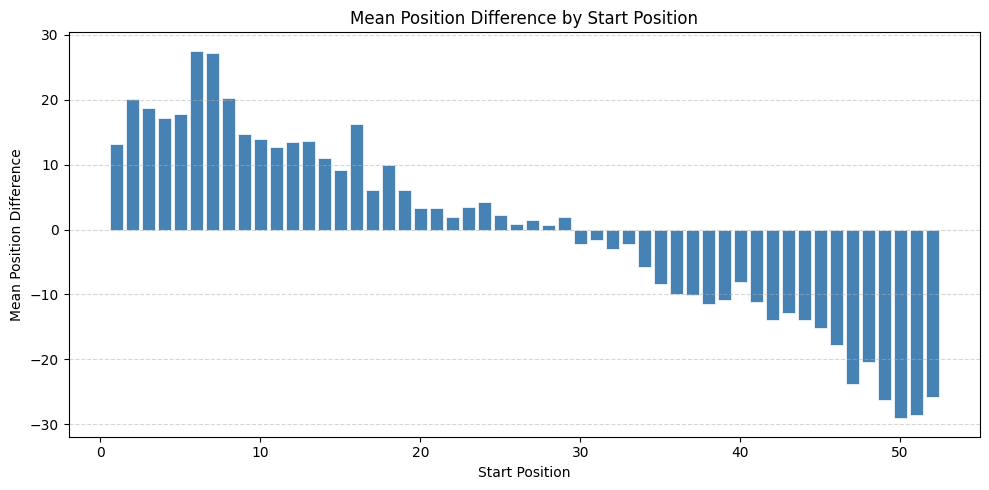

In [11]:
mean_by_start = df.groupby('Start Position')['Position Difference'].mean()

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(mean_by_start.index, mean_by_start.values, color='steelblue', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Start Position')
ax.set_ylabel('Mean Position Difference')
ax.set_title('Mean Position Difference by Start Position')
ax.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
mean_abs_by_start = df.groupby('Start Position')['Position Difference'].apply(lambda x: x.abs().mean())

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(mean_abs_by_start.index, mean_abs_by_start.values, color='steelblue', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Start Position')
ax.set_ylabel('Mean Absolute Position Difference')
ax.set_title('Mean Absolute Position Difference by Start Position')
ax.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()


In [ ]:
median_abs_by_start = df.groupby('Start Position')['Position Difference'].apply(lambda x: x.abs().median())

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(median_abs_by_start.index, median_abs_by_start.values, color='steelblue', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Start Position')
ax.set_ylabel('Median Absolute Position Difference')
ax.set_title('Median Absolute Position Difference by Start Position')
ax.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()


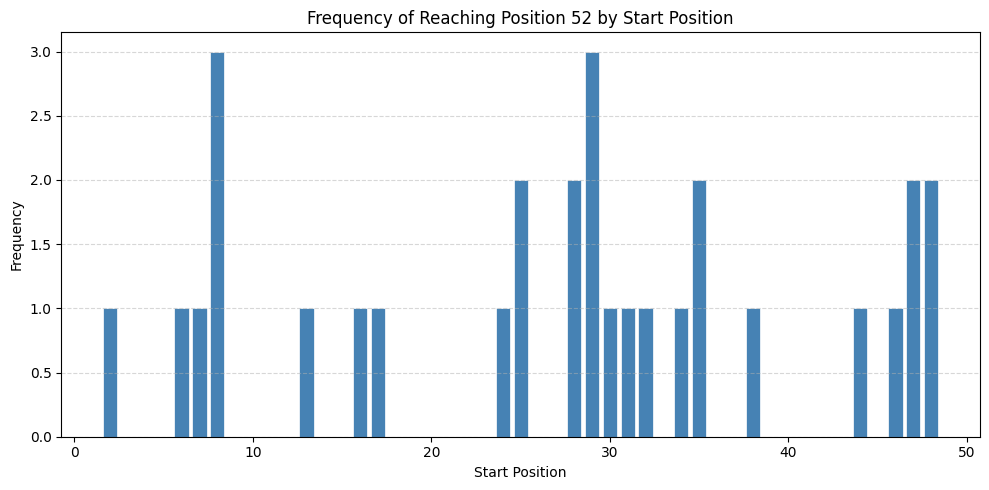

In [17]:
to_top = df[df['End Position'] == 52]
freq_by_start = to_top.groupby('Start Position').size()

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(freq_by_start.index, freq_by_start.values, color='steelblue', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Start Position')
ax.set_ylabel('Frequency')
ax.set_title('Frequency of Reaching Position 52 by Start Position')
ax.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()